In [8]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [9]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../MeshPipeline/outputs/ParamOptimisation/optimiseV2') # path to parent of output_root in set_parameters
study_prefix = 'StMmLt-study1' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs/{study_prefix}') # path dir to save outputs in
suffixes = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l'] # individual study identifier (end of dir name of output_root in set_parameters)

In [104]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
get_params3d(root_dir, study_prefix, suffixes).fillna(0).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [10]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [11]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

df = df[df['bone']==bone]

print(len(df))

1512


Highest element count:
	14874R - 1214565


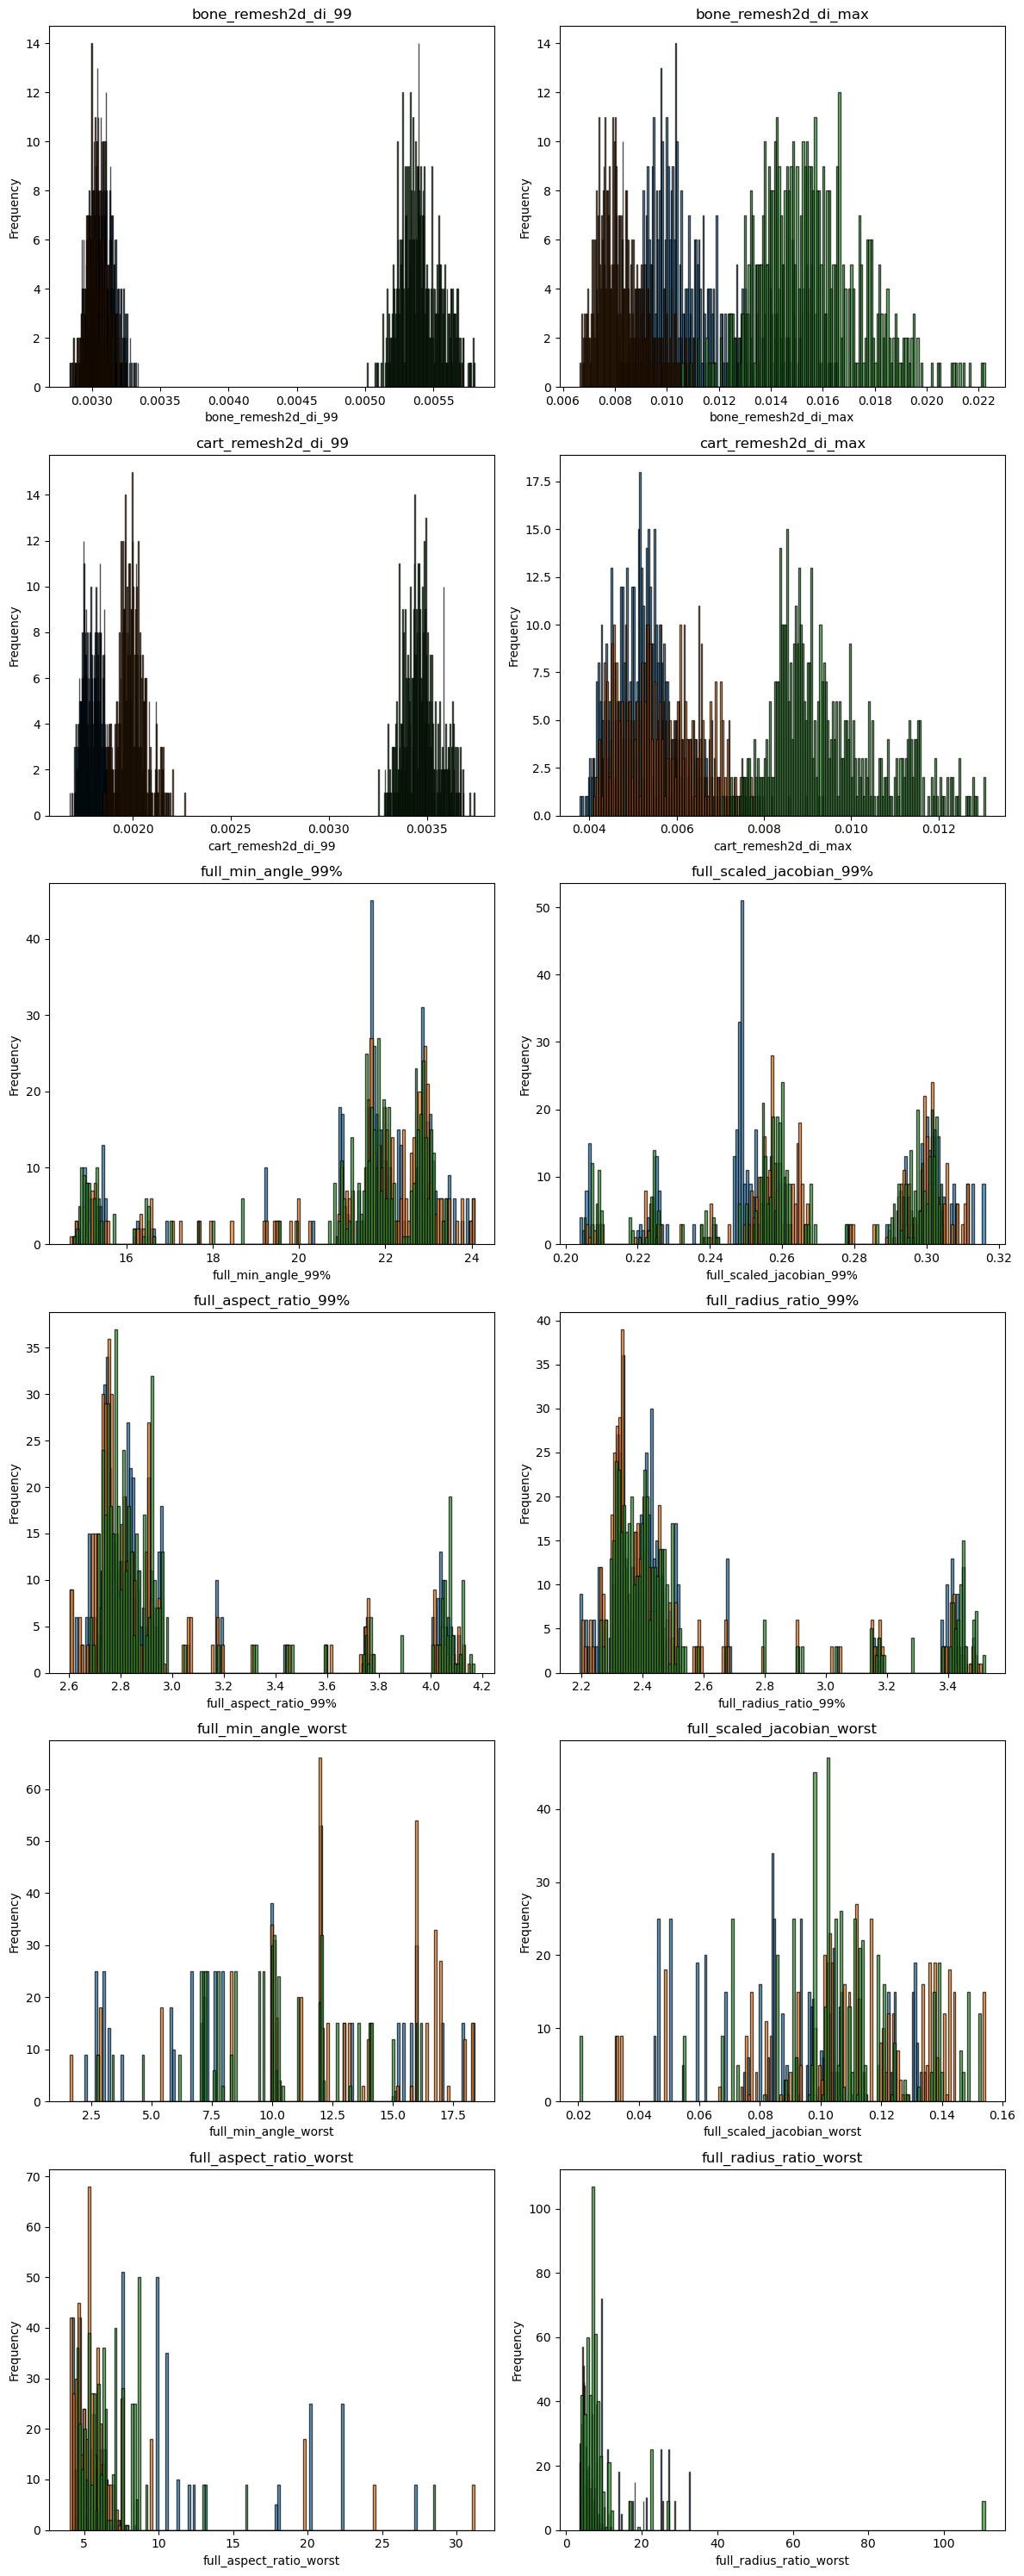

In [12]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 10)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [13]:
q_weight = 1 

chosen_metrics = {

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q_weight
    },

    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q_weight
    },
}

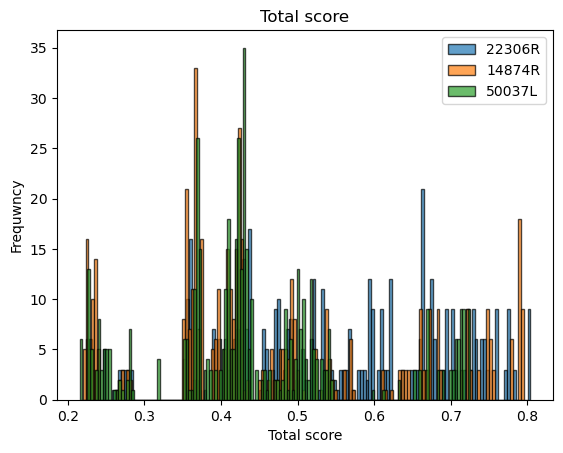

In [14]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_score.merge(
    df_qual,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/10), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    ax.legend()

In [15]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank

,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,p_h,mean_rank,median_rank,best_rank,n_runs
459,0.4,6,20,0,12.0,47.166667,20.0,2.0,3
476,0.4,6,30,0,12.0,47.166667,20.0,2.0,3
491,0.4,6,40,0,12.0,47.166667,20.0,2.0,3
473,0.4,6,20,40,12.0,50.500000,23.0,5.0,3
488,0.4,6,30,40,12.0,50.500000,23.0,5.0,3
...,...,...,...,...,...,...,...,...,...
376,0.4,3,20,10,1.5,488.000000,485.0,479.0,3
358,0.4,3,10,10,1.5,488.000000,485.0,479.0,3
40,0.2,3,20,10,1.5,496.000000,497.0,488.0,3
4,0.2,3,0,10,1.5,496.000000,497.0,488.0,3


In [16]:
sub = '14874R'
#sub = '22306R'
#sub = '50037L'
df_score_param[(df_score_param['sub']==sub)&(df_score_param['cgal_params.sizing_field.d0']<10)][[x for x in df_score_param.columns if 'worst' not in x]].head(7)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,p_h
9,14874R,tpm,0-1-18-0g,0.802014,0.580983,1.0,1.0,0.796005,2.0,0.3,6,30,0,8.5
10,14874R,tpm,0-1-21-0g,0.802014,0.580983,1.0,1.0,0.796005,2.0,0.3,6,40,0,8.5
11,14874R,tpm,0-2-33-0a,0.802014,0.580983,1.0,1.0,0.796005,2.0,0.3,6,20,0,8.5
12,14874R,tpm,0-1-13-0d,0.801910,0.580984,1.0,1.0,0.795992,5.0,0.3,6,30,40,8.5
13,14874R,tpm,0-1-23-0j,0.801910,0.580984,1.0,1.0,0.795992,5.0,0.3,6,20,40,8.5
14,14874R,tpm,0-1-15-0d,0.801910,0.580984,1.0,1.0,0.795992,5.0,0.3,6,40,40,8.5
15,14874R,tpm,0-1-14-0d,0.799041,0.579240,1.0,1.0,0.795415,8.0,0.3,6,40,30,8.5


In [29]:
#sub = '14874R'
sub = '22306R'
#sub = '50037L'
df_score_param[(df_score_param['sub']==sub)&(df_score_param['cgal_params.sizing_field.d0']<10)][[x for x in df_score_param.columns if 'worst' not in x]].head(7)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,p_h
0,22306R,tpm,0-2-30-0h,0.802167,0.553549,1.0,1.0,0.804128,2.0,0.4,6,30,0,12.0
1,22306R,tpm,0-2-33-0h,0.802167,0.553549,1.0,1.0,0.804128,2.0,0.4,6,40,0,12.0
2,22306R,tpm,0-3-51-0b,0.802167,0.553549,1.0,1.0,0.804128,2.0,0.4,6,20,0,12.0
3,22306R,tpm,0-2-23-0e,0.801966,0.553597,1.0,1.0,0.804109,5.0,0.4,6,40,40,12.0
4,22306R,tpm,0-2-21-0e,0.801966,0.553597,1.0,1.0,0.804109,5.0,0.4,6,30,40,12.0
5,22306R,tpm,0-2-35-0k,0.801966,0.553597,1.0,1.0,0.804109,5.0,0.4,6,20,40,12.0
6,22306R,tpm,0-2-34-0k,0.798471,0.551209,1.0,1.0,0.803374,8.0,0.4,6,20,30,12.0


In [30]:
#sub = '14874R'
#sub = '22306R'
sub = '50037L'
df_score_param[(df_score_param['sub']==sub)&(df_score_param['cgal_params.sizing_field.d0']<10)][[x for x in df_score_param.columns if 'worst' not in x]].head(7)

,sub,bone,run_id,full_min_angle_99%,full_scaled_jacobian_99%,full_aspect_ratio_99%,full_radius_ratio_99%,total,rank_within_case,cgal_params.sizing_field.taper_size,cgal_params.sizing_field.d0,cgal_params.perturb.sliver_bound,cgal_params.exude.sliver_bound,p_h
120,50037L,tpm,0-0-6-0i,0.768841,0.515596,1.0,1.0,0.725385,2.0,0.2,6,30,0,5.0
121,50037L,tpm,0-1-15-0c,0.768841,0.515596,1.0,1.0,0.725385,2.0,0.2,6,20,0,5.0
122,50037L,tpm,0-0-9-0i,0.768841,0.515596,1.0,1.0,0.725385,2.0,0.2,6,40,0,5.0
123,50037L,tpm,0-0-11-0l,0.768575,0.515540,1.0,1.0,0.725345,5.0,0.2,6,20,40,5.0
124,50037L,tpm,0-0-5-0f,0.768575,0.515540,1.0,1.0,0.725345,5.0,0.2,6,30,40,5.0
125,50037L,tpm,0-0-7-0f,0.768575,0.515540,1.0,1.0,0.725345,5.0,0.2,6,40,40,5.0
129,50037L,tpm,0-0-10-0l,0.762393,0.510233,1.0,1.0,0.723909,8.0,0.2,6,20,30,5.0


In [31]:
df_score_qual[(df_score_qual['sub']==sub)][['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_y' in x]].head(7)

,sub,bone,run_id,full_min_angle_worst_y,full_min_angle_99%_y,full_radius_ratio_worst_y,full_radius_ratio_99%_y,full_aspect_ratio_worst_y,full_aspect_ratio_99%_y,full_scaled_jacobian_worst_y,full_scaled_jacobian_99%_y
120,50037L,tpm,0-0-6-0i,13.555315,23.065218,4.193343,2.311689,4.641081,2.737521,0.13905,0.303119
121,50037L,tpm,0-1-15-0c,13.555315,23.065218,4.193343,2.311689,4.641081,2.737521,0.13905,0.303119
122,50037L,tpm,0-0-9-0i,13.555315,23.065218,4.193343,2.311689,4.641081,2.737521,0.13905,0.303119
123,50037L,tpm,0-0-11-0l,13.555315,23.057238,4.193343,2.312218,4.641081,2.738291,0.13905,0.303108
124,50037L,tpm,0-0-5-0f,13.555315,23.057238,4.193343,2.312218,4.641081,2.738291,0.13905,0.303108
125,50037L,tpm,0-0-7-0f,13.555315,23.057238,4.193343,2.312218,4.641081,2.738291,0.13905,0.303108
129,50037L,tpm,0-0-10-0l,13.555315,22.871797,4.193343,2.325885,4.641081,2.757394,0.13905,0.302047


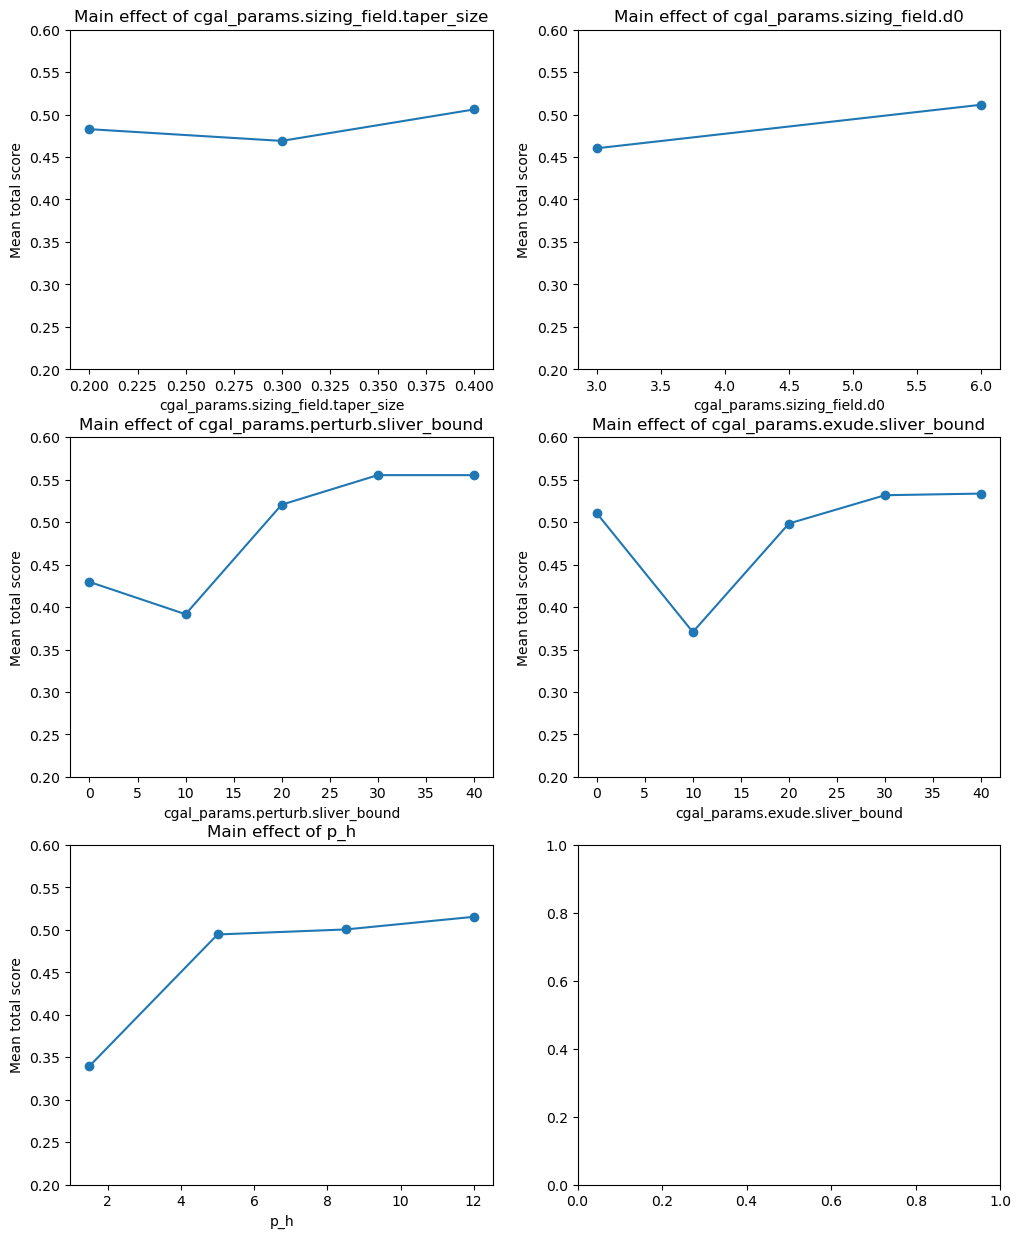

In [123]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for i, p in enumerate(df_param.columns[3:]):
    eff = (
        df_score_param
        .groupby(p)['total']
        .mean()
        .reset_index()
        .sort_values(p)
    )

    ax[i].plot(eff[p], eff['total'], marker='o')
    ax[i].set_title(f'Main effect of {p}')
    ax[i].set_xlabel(p)
    ax[i].set_ylabel('Mean total score')

    ax[i].set_ylim([0.2, 0.6])


## Thoughts
- All 3 preferred d0 = 6 and perturb = 20
- All preferred exude != 10
- preferred taper size was different for all 3
    - Geometry dependent? 
    - can investigate this for all
- p_h beyond 5 gave reasonalbe results for all 3, with each prefering a different one. 
    - Geometry dependent? 5 provides slightly more natural tapering. 
    - can investigate this for all

---
- Exude = 0 or 20 would try to improve
- Exude = 10 was worst but it exited with code 0, as the bound was hit, so stopped trying or didn't do anything
- perturb = 0 or 10 would exit code 0, stopped trying or didn't do anything
    - seems like perturb = 0 and exude = 0 have different stopping criteria
- may be the case that for both exude and perturb it is best to set them above what is possible and make sure they exit code 2.
---
- should do some runs with 14874R with lower facet distance to prevent holes around the edge of the cartilage

## Plan
 #### study: d-done, e-done, f-done
 - look at perturb / exude [30, 40] combinations
 #### study: g-done, h-done, i-done
 - look at perturb [30, 40], exude [0, 10, 20]
 #### study: j-done, k-done, l-done
 - look at perturb [0, 10, 20], exude [30, 40]

---
### All 3 subjects aggree on perturb ≥ 20, exude = 0(, and d0 bigger)
 - Do combos of odt lloyd perturb exude
 - only use 50037L - has lowest scores (also lowest runtimes)
    - should play around with lloyd and odt iterations to figure out what is reasonable / what hits time limits.
 - set other params to 
 - acknowledge that larger d0 is better for obvious reasons and say that d0 and min_size will be dealt with later to ensure node / element counts are manageable. - or do things other way around...
 ---
 - Then find best geometry based params accross all subjects.
